# Forecasting hierárquico com reconciliação ótima — M5, Califórnia

**V1 · notebook reprodutível.** Projeto 4 do `data-science-lab`.

Hierarquia real do M5 (estado → loja → categoria → departamento, 45 séries diárias),
baselines clássicos fortes (SeasonalNaive, AutoETS, AutoARIMA) e três esquemas de
reconciliação (BottomUp, TopDown, MinT-shrink), avaliados em backtest expanding-window
de 4 janelas × 28 dias — o protocolo canônico do M5, sem look-ahead.

In [1]:
from src import config as C
from src import run_benchmark as R

Y, S, tags = R.load_hierarchy()
print("séries por nível:", {k: len(v) for k, v in tags.items()})
Y.tail(3)

séries por nível: {'state_id': 1, 'state_id/store_id': 4, 'state_id/store_id/cat_id': 12, 'state_id/store_id/cat_id/dept_id': 28}


,unique_id,ds,y
88601,CA/CA_4/HOUSEHOLD/HOUSEHOLD_2,2016-06-17,152.0
88602,CA/CA_4/HOUSEHOLD/HOUSEHOLD_2,2016-06-18,201.0
88603,CA/CA_4/HOUSEHOLD/HOUSEHOLD_2,2016-06-19,162.0


## Backtest

4 janelas de 28 dias; a cada janela os modelos são reestimados só com o passado e as
previsões reconciliadas com matriz S e resíduos in-sample (MinT-shrink).

> ⏱️ ~10 min na primeira execução (AutoARIMA em 45 séries × 4 janelas). Os resultados
> ficam em `outputs/benchmark_results.csv`.

In [2]:
import pandas as pd
from pathlib import Path

cache = C.OUTPUTS / "benchmark_results.csv"
if cache.exists():
    res = pd.read_csv(cache)
else:
    res = R.run()

tab = (res.groupby(["modelo", "reconciliacao"])["mase"].mean().unstack()
       [["base", "BottomUp", "TopDown", "MinTrace"]].round(3))
display(tab)

reconciliacao,base,BottomUp,TopDown,MinTrace
modelo,,,,
AutoARIMA,0.867,0.886,0.864,0.841
AutoETS,0.817,0.810,0.818,0.817
SeasonalNaive,0.991,0.991,0.991,0.991


  fig -> D:\labs\data-science-lab\forecasting-hierarquico-m5\outputs\figures\mase_by_level.png


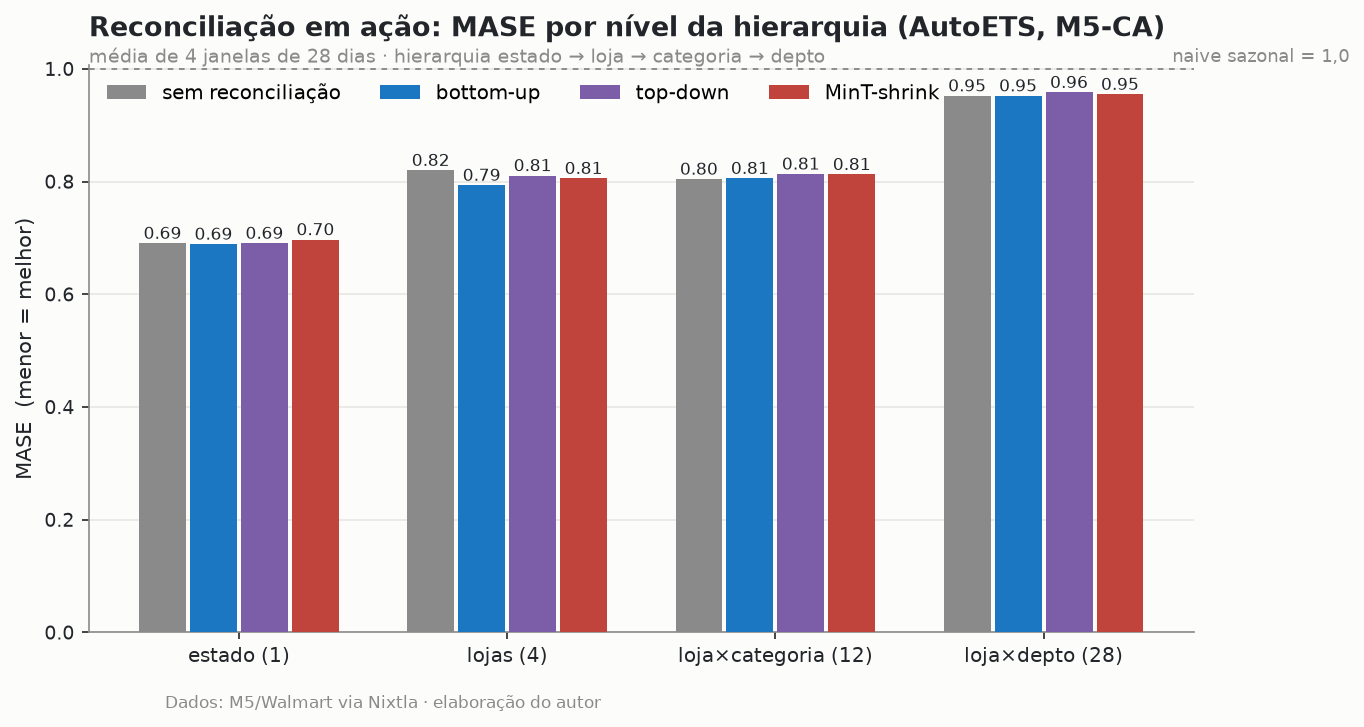

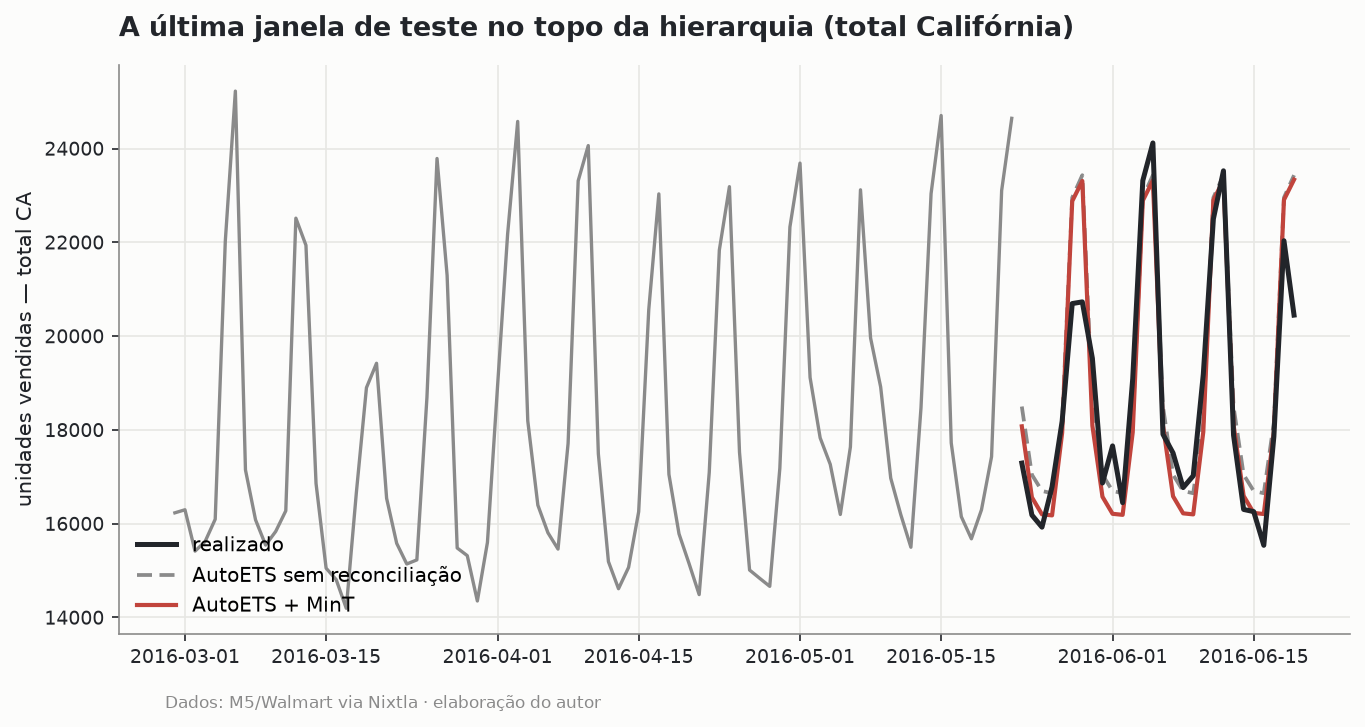

In [3]:
R.fig_mase(res)
from IPython.display import Image, display
display(Image(str(C.FIGURES / "mase_by_level.png")))
display(Image(str(C.FIGURES / "example_forecast.png")))

## Conclusão honesta

Ver `outputs/results.md` para a tabela definitiva método × reconciliação × nível.
Os pontos que sobrevivem a qualquer rodada:

- **ETS bem ajustado é um adversário duríssimo** — é a lição da competição M5 inteira.
- **Reconciliação não é cosmética**: além de garantir coerência entre níveis
  (as previsões somam), MinT-shrink redistribui informação usando a covariância dos
  erros in-sample.
- **TopDown degrada as folhas**: proporções históricas apagam a dinâmica local.

**V2**: desafiante neural (TFT/N-BEATS) sob o MESMO protocolo, WRMSSE oficial e
hierarquia completa até o item (30 mil séries).